In [33]:
from glob import glob
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import anndata
import pickle
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import tarfile
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from scipy import stats
import seaborn as sns
import collections
import scirpy as ir
import random
from pathlib import Path
import muon as mu
random.seed(10)
#https://icbi-lab.github.io/scirpy/latest/tutorials/tutorial_3k_tcr.html
# https://icbi-lab.github.io/scirpy-paper/wu2020.html

In [34]:
# Paths — relative to this notebook's location (GVHD_Reproducibility-main/Sc&TCR_Pipelines/)
PROJECT_ROOT = Path('../..')

# Input paths
TCELL_ANN_CONCAT_REFINED_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_Migration_refined.h5ad'

# Output paths — figures
FIGURES_SC_DIR           = PROJECT_ROOT / 'Figures' / 'single_cell_figures'

IMMUNE_RECEPTOR_SUMMARY_CSV = PROJECT_ROOT / 'adata_file' / 'immune_receptor_summary_by_sample.csv'

In [35]:
# version of scirpy
print(ir.__version__)

0.22.0


In [36]:
tcell_ann_concat = anndata.read_h5ad(TCELL_ANN_CONCAT_REFINED_PATH)

In [37]:
tcell_ann_concat

AnnData object with n_obs × n_vars = 38539 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'DoT', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_0.15', 'B_doublet', 'Myeloid_doublet', 'Macrophage_doublet', 'Monocyte_doublet', 'Epithelial_doublet', 'Fibroblast_doublet', 'plasma_doublet2', 'if_doublet', 'T_cell_subsets', 'PatientID_Time', 'PatientID_Tissue_Loc', 'PatientID_Grade', 'PatientID_Grade_Time_Loc', 'T_cell_subsets_plot', 'T_cell_subsets_reordered', 'SampleID_Grade', 'GVHD_Grade', 'leiden_48', 'ptcy', 'PatientID_Grade_Ptcy', 'SampleID_Ptcy', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id

In [38]:
# Step 1: Count the number of observations in each category
category_counts = tcell_ann_concat.obs["T_cell_subsets_refined_resi"].value_counts()

# Step 2: Sort the categories by the counts
sorted_categories = category_counts.index.tolist()

# Step 3: Reorder the categories based on the sorted order
tcell_ann_concat.obs['T_cell_subsets_refined_resi'] = tcell_ann_concat.obs['T_cell_subsets_refined_resi'].astype('category')


In [39]:
category_counts

T_cell_subsets_refined_resi
CD8+ effector T cells                           8017
CD4+ effector T cells                           7216
Low CD3                                         5477
CD8+ cytotoxic unconventional T cells           3844
CD8+ proliferating T cells                      2884
CD4+ central memory T cells                     2824
CD8+ tissue resident memory T cells             2011
CD4+ regulatory T cells                         1795
CD8+ Hobit- resident memory T cells             1736
CD8+ homeostatic unconventional T cells         1373
CD8+ Hobit+ PRDM1-lo resident memory T cells     838
CD8+ Hobit+ PRDM1+ resident memory T cells       524
Name: count, dtype: int64

In [40]:
tcell_ann_concat.obs['clone_id_size'] = tcell_ann_concat.obs['clone_id_size'].astype(float)

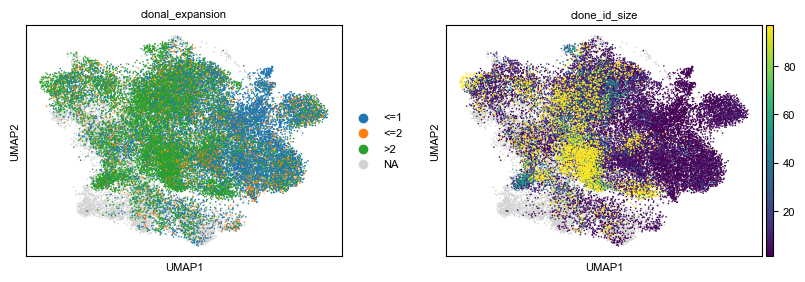

In [41]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 3)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

# Set NaN (cells without TCR data) to appear gray
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='lightgray')

# Generate UMAP plot with larger dots
sc.pl.umap(tcell_ann_concat, color=["clonal_expansion", "clone_id_size"], size=5, show=False, vmax="p90", color_map=cmap)

# Save the plot manually with DPI 300
plt.savefig(FIGURES_SC_DIR / 'umap_clonal_expansion_cloneid.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clonal_expansion_cloneid.png', dpi=300, bbox_inches='tight', transparent=True)
plt.savefig(FIGURES_SC_DIR / 'umap_clonal_expansion_cloneid.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [42]:
tcell_ann_concat.obs['receptor_type']

R096_Tc17_up_AAACCTGGTTGGAGGT-1    TCR
R096_Tc17_up_AAACCTGTCTATCCTA-1    NaN
R096_Tc17_up_AAACGGGAGGATGCGT-1    TCR
R096_Tc17_up_AAACGGGGTAAATGAC-1    TCR
R096_Tc17_up_AAAGATGCAAACTGTC-1    NaN
                                  ... 
UA41_TGTTCCGAGGACAGCT-1            NaN
UA41_TTAGGACGTTGTTTGG-1            NaN
UA41_TTAGGACTCCCAAGAT-1            NaN
UA41_TTCGAAGTCCGCATCT-1            NaN
UA41_TTGCGTCCAAGAAAGG-1            NaN
Name: receptor_type, Length: 38539, dtype: category
Categories (1, object): ['TCR']

In [43]:
# Count cells with has_ir=True per sample ID
ir_true_per_sample = tcell_ann_concat.obs.groupby("SampleID")["receptor_type"].apply(lambda x: (x == "TCR").sum())
print(ir_true_per_sample)
# Count total cells per sample ID
total_cells_per_sample = tcell_ann_concat.obs["SampleID"].value_counts()

# Calculate percentage
ir_percentage = (ir_true_per_sample / total_cells_per_sample) * 100

clone_counts = tcell_ann_concat.obs.groupby("SampleID")["cc_aa_identity"].apply(
        lambda x: x.dropna().nunique()
    )
print(clone_counts)

# Map SampleID to PatientID
sample_to_patient = tcell_ann_concat.obs.groupby("SampleID")["PatientID"].first()

# Create a summary DataFrame
ir_summary = pd.DataFrame({
    "Total_Cells": total_cells_per_sample,
    "IR_Positive_Cells": ir_true_per_sample,
    "IR_Percentage": ir_percentage,
    "Clone_counts": clone_counts,
    "PatientID": sample_to_patient
})



# Your specified order of SampleIDs
custom_order = [
    "UA21", "UA22", "UA14", "UA19", "UA20", "R096_Tc17_up", "UA02", "UA01", "UA13", "UA09", 
    "UA10", "UA33", "R096_Tc17_low", "UA07", "RH07", "UA15", "UA12", "UA32", "UA11", "RH01", 
    "UA30", "UA37", "UA36", "RH03", "RH05", "RH02", "RH09", "UA35", "UA05", "RH08", "UA34", 
    "UA31", "UA39", "UA38", "RH12", "UA41", "RH06", "RH13", "UA08", "UA40", "RH11", "RH04", 
    "RH10", "UA06", "UA04", "UA24", "UA26", "UA03", "RH14", "UA23"
]



# Filter the DataFrame to only include the samples in the custom order
# and reorder according to the custom order
ir_summary_ordered = ir_summary.loc[custom_order]
print(ir_summary_ordered)
# Save the DataFrame to a CSV file
ir_summary_ordered.to_csv(IMMUNE_RECEPTOR_SUMMARY_CSV)
    
print(f"Summary saved to '{IMMUNE_RECEPTOR_SUMMARY_CSV}'")

SampleID
R096_Tc17_low     873
R096_Tc17_up     1728
RH01              640
RH02                0
RH03              269
RH04               34
RH05              267
RH06               88
RH07              627
RH08              164
RH09              193
RH10               48
RH11               62
RH12              142
RH13               91
RH14                9
UA01             1115
UA02             1494
UA03                5
UA04               14
UA05              139
UA06               33
UA07              714
UA08               64
UA09              892
UA10              803
UA11              558
UA12              566
UA13             1013
UA14             2245
UA15              535
UA19             1857
UA20             1934
UA21             2343
UA22             3523
UA23                3
UA24               15
UA26                6
UA30              531
UA31              172
UA32              506
UA33              758
UA34              128
UA35              176
UA36              305
U

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_45611/3206272701.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_true_per_sample = tcell_ann_concat.obs.groupby("SampleID")["receptor_type"].apply(lambda x: (x == "TCR").sum())
/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_45611/3206272701.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_counts = tcell_ann_concat.obs.groupby("SampleID")["cc_aa_identity"].apply(
/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_45611/3206272701.py:16: FutureWarning: The default of observed=False is deprecated and will be changed t

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


<Axes: >

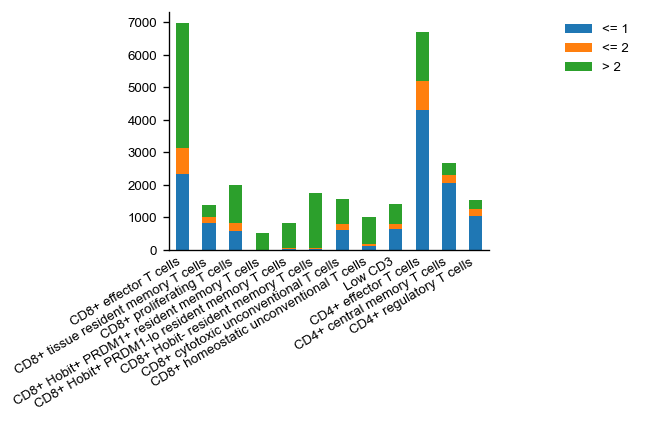

In [44]:
import pandas as pd

# Specify the desired order of clusters
desired_order = ['CD8+ effector T cells','CD8+ tissue resident memory T cells','CD8+ proliferating T cells', 'CD8+ Hobit+ PRDM1+ resident memory T cells', 'CD8+ Hobit+ PRDM1-lo resident memory T cells','CD8+ Hobit- resident memory T cells', 'CD8+ cytotoxic unconventional T cells','CD8+ homeostatic unconventional T cells','Low CD3', 
                  'CD4+ effector T cells','CD4+ central memory T cells','CD4+ regulatory T cells']  # your desired order

# Reorder the categories
tcell_ann_concat.obs['T_cell_subsets_refined_resi'] = pd.Categorical(
    tcell_ann_concat.obs["T_cell_subsets_refined_resi"],
    categories=desired_order,
    ordered=True
)

ir.pl.clonal_expansion(tcell_ann_concat, groupby="T_cell_subsets_refined_resi", clip_at=3, normalize=False)

In [45]:
# Get current categories and assign gray to 'NA'
tcell_ann_concat.obs['clonal_expansion'] = tcell_ann_concat.obs['clonal_expansion'].astype(str).replace('nan', 'NA')
tcell_ann_concat.obs['clonal_expansion'] = pd.Categorical(tcell_ann_concat.obs['clonal_expansion'])

# Build palette: get existing colors from scanpy then add gray for NA
cats = tcell_ann_concat.obs['clonal_expansion'].cat.categories.tolist()
existing_colors = sc.pl.palettes.default_20[:len(cats)]
palette = {cat: col for cat, col in zip(cats, existing_colors)}
palette['NA'] = 'lightgray'


Processing GVHD grade: Severe


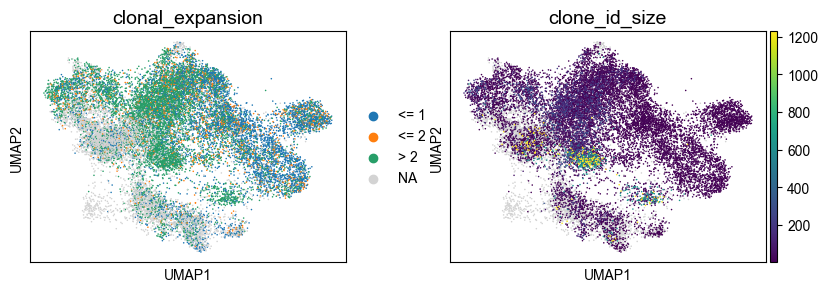

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


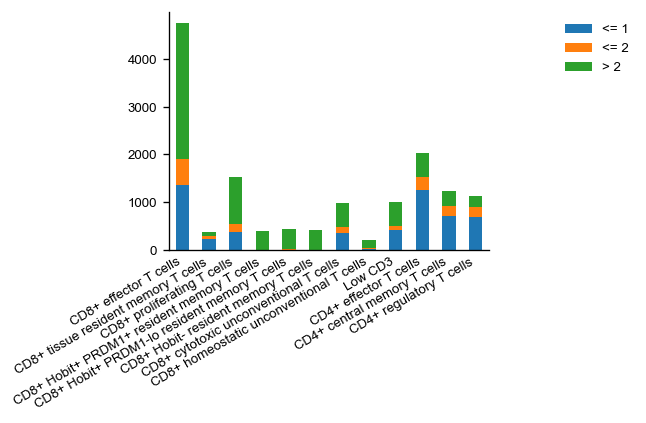

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/util/__init__.py:458: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return 1 / cast(np.ndarray, obs.groupby(normalize_col)[normalize_col].transform("count").values)


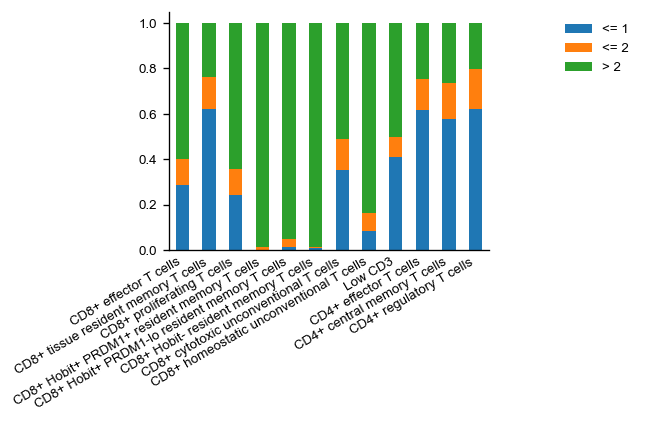

Completed processing for Severe GVHD
Processing GVHD grade: Mild


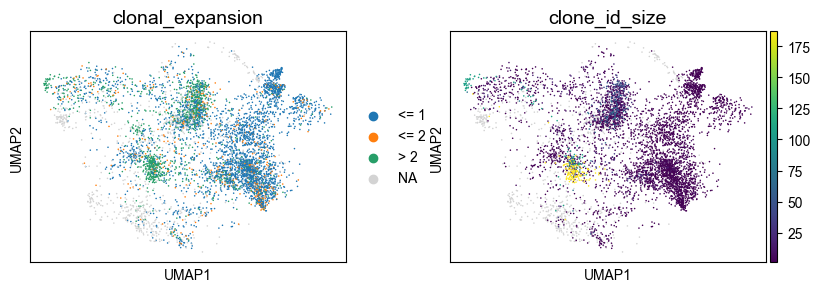

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


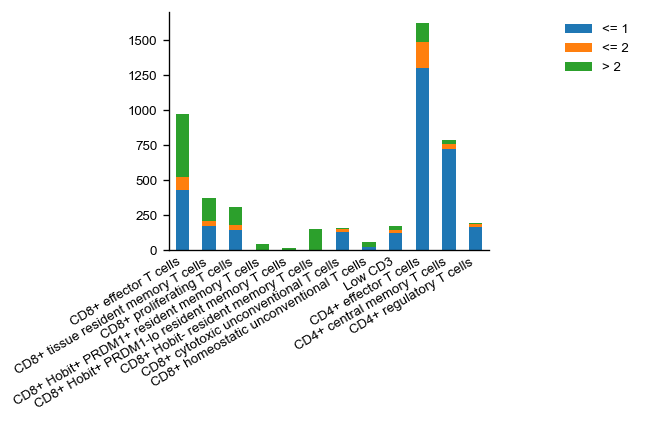

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/util/__init__.py:458: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return 1 / cast(np.ndarray, obs.groupby(normalize_col)[normalize_col].transform("count").values)


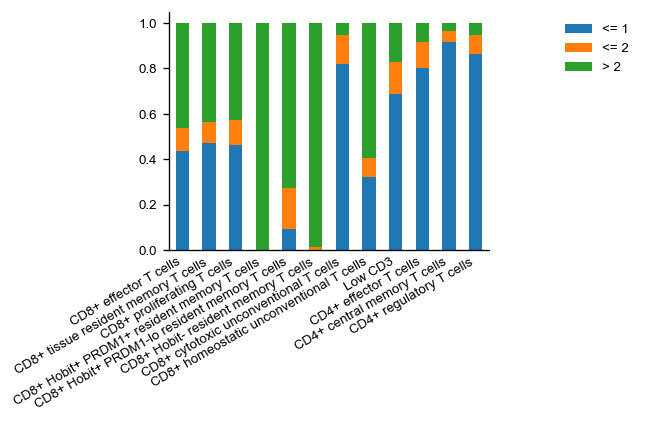

Completed processing for Mild GVHD
Processing GVHD grade: No


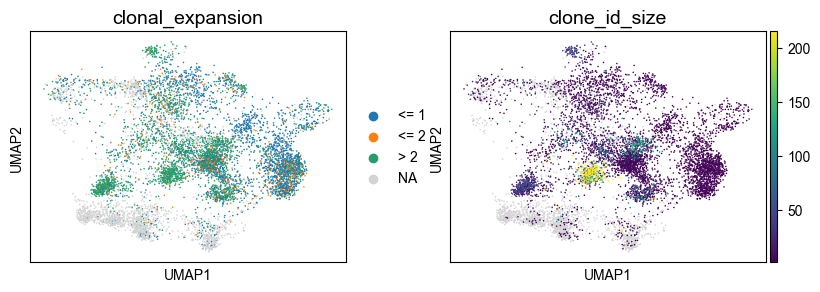

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


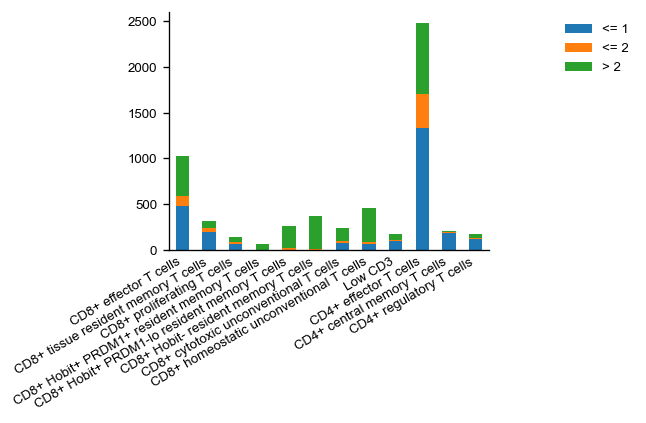

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/util/__init__.py:458: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return 1 / cast(np.ndarray, obs.groupby(normalize_col)[normalize_col].transform("count").values)


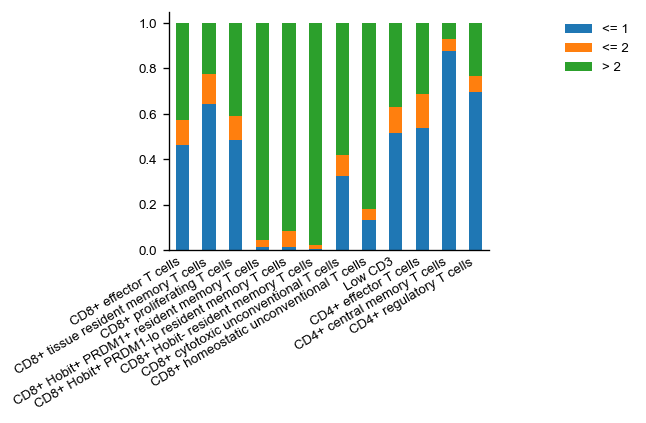

Completed processing for No GVHD
Processing GVHD grade: ND


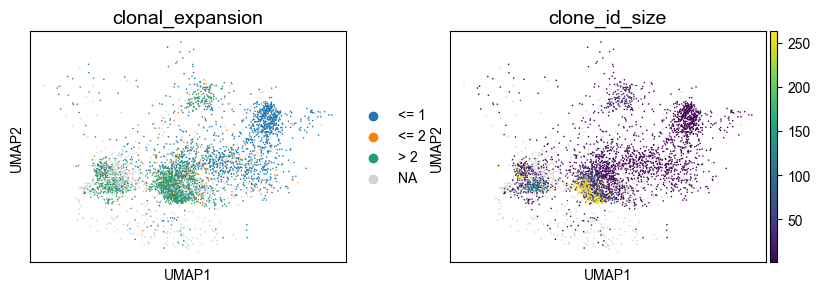

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


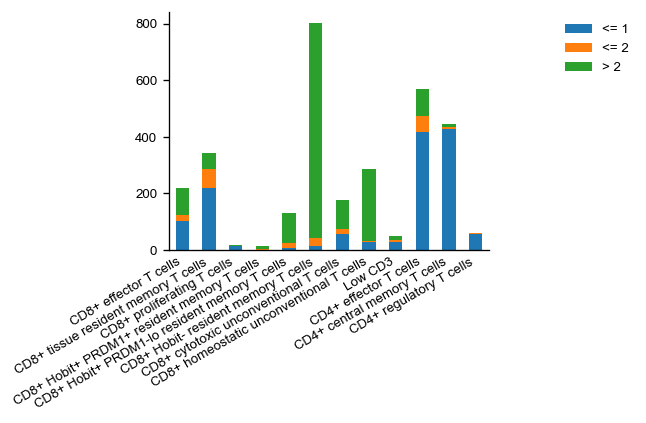

/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)
/Users/lingting/ENTER/envs/scirpy/lib/python3.11/site-packages/scirpy/util/__init__.py:458: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return 1 / cast(np.ndarray, obs.groupby(normalize_col)[normalize_col].transform("count").values)


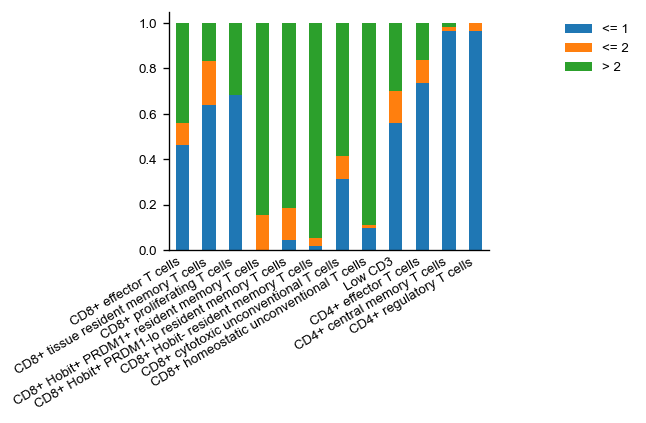

Completed processing for ND GVHD
All GVHD grades processed successfully


In [46]:
# Define the GVHD grade categories
gvhd_grades = ['Severe', 'Mild', 'No', 'ND']

# Update matplotlib parameters
mpl.rcParams.update({
    'font.size': 10,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (4, 3)  # Set default figure size to 4×3 inches
})
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10

for grade in gvhd_grades:
    print(f"Processing GVHD grade: {grade}")
    
    tcell_grade = tcell_ann_concat[tcell_ann_concat.obs['GVHD_Grade_1'] == grade].copy()
    
    if tcell_grade.shape[0] == 0:
        print(f"No cells found for GVHD grade: {grade}")
        continue
    
    # Compute clonal expansion
    ir.tl.clonal_expansion(tcell_grade)
    
    # Convert NaN to 'NA' string and rebuild as Categorical
    tcell_grade.obs['clonal_expansion'] = (
        tcell_grade.obs['clonal_expansion']
        .astype(str)
        .replace('nan', 'NA')
    )
    tcell_grade.obs['clonal_expansion'] = pd.Categorical(tcell_grade.obs['clonal_expansion'])
    
    # Build palette with gray for NA
    cats = tcell_grade.obs['clonal_expansion'].cat.categories.tolist()
    existing_colors = sc.pl.palettes.default_20[:len(cats)]
    palette = {cat: col for cat, col in zip(cats, existing_colors)}
    palette['NA'] = 'lightgray'

    # UMAP for clonal_expansion with explicit palette
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='lightgray')
    sc.pl.umap(tcell_grade, color=["clonal_expansion", "clone_id_size"], size=5, show=False,
               vmax="p99", color_map=cmap, na_color="lightgray", palette=palette)
    
    grade_lower = grade.lower()
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_umap_clonal_expansion_cloneid.pdf',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_umap_clonal_expansion_cloneid.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_umap_clonal_expansion_cloneid.svg',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

    # Non-normalized plot
    ir.pl.clonal_expansion(tcell_grade, groupby="T_cell_subsets_refined_resi", clip_at=3, normalize=False,
                           title=f"{grade} GVHD - Non-normalized")
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_non_normalized.pdf',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_non_normalized.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_non_normalized.svg',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

    # Normalized plot
    ir.pl.clonal_expansion(tcell_grade, groupby="T_cell_subsets_refined_resi", clip_at=3,
                           title=f"{grade} GVHD - Normalized")
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_normalized.pdf',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_normalized.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(FIGURES_SC_DIR / f'{grade_lower}_clonal_expansion_normalized.svg',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

    print(f"Completed processing for {grade} GVHD")

print("All GVHD grades processed successfully")